# Ethiopia Climate EDA (Task 2)

This notebook follows Task 2 requirements: data profiling, cleaning, and exploratory data analysis.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ethiopia.csv")

df["Country"] = "Ethiopia"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Data Loading & Date Processing

The dataset was loaded and a proper datetime column was created using YEAR and DOY. A Country column and MONTH column were also added for analysis.

In [21]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
MONTH          0
dtype: int64

## Missing Values Handling

NASA sentinel values (-999) were replaced with NaN. Missing values were then analyzed across all columns.

In [22]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## Duplicate Check

No duplicate rows were found in the dataset, so no data removal was required.

In [23]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Summary Statistics

The dataset contains temperature, rainfall, humidity, and wind variables. Values show seasonal variation typical of Ethiopian climate patterns.

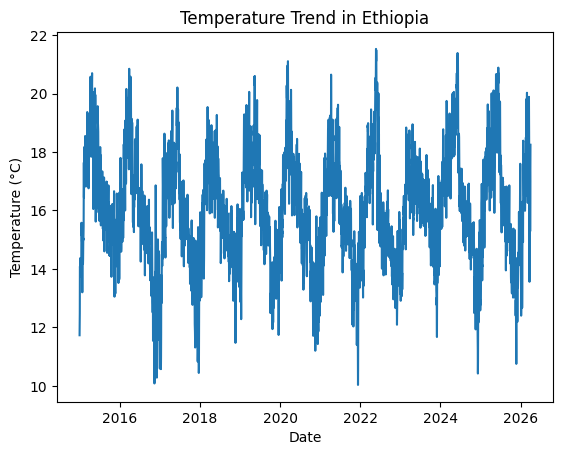

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["DATE"], df["T2M"])
plt.title("Temperature Trend in Ethiopia")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

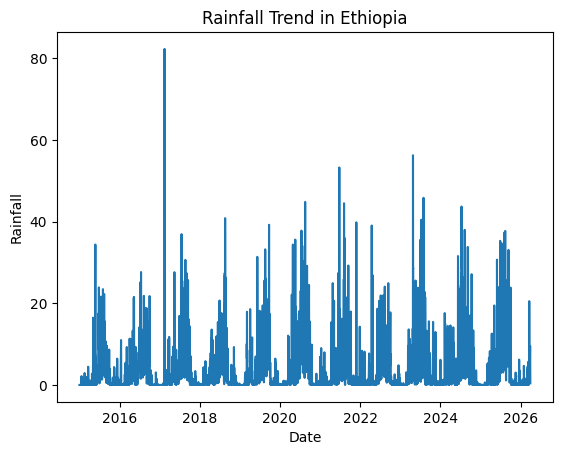

In [25]:
plt.figure()
plt.plot(df["DATE"], df["PRECTOTCORR"])
plt.title("Rainfall Trend in Ethiopia")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

## Time Series Analysis

Temperature and rainfall show clear seasonal patterns over time, indicating alternating wet and dry seasons in Ethiopia.

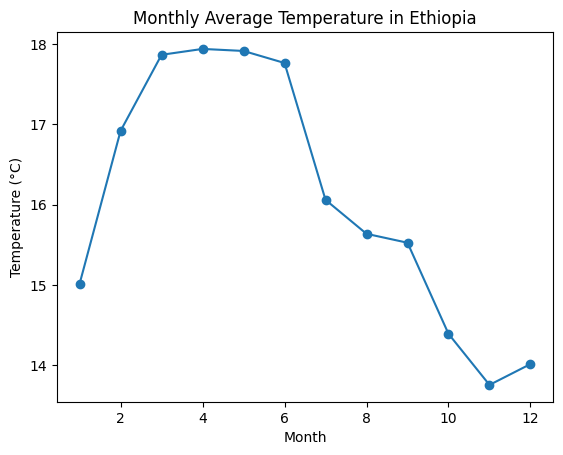

In [26]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

plt.figure()
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

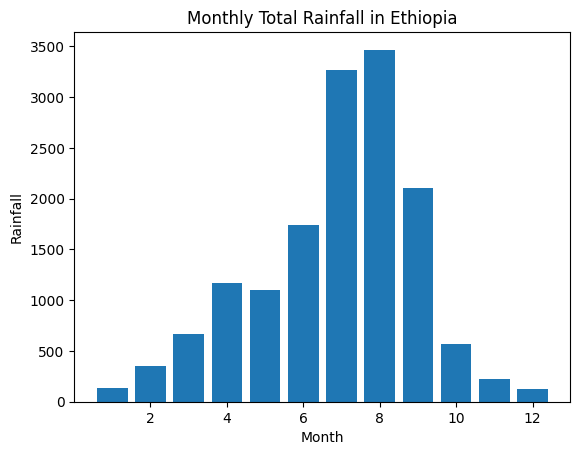

In [27]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

plt.figure()
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

## Monthly Climate Patterns

The analysis shows clear seasonal patterns in Ethiopia:

- Temperature varies across months, showing seasonal warming and cooling trends.
- Rainfall is highly seasonal, with clear wet and dry periods throughout the year.

These patterns indicate strong climate seasonality in the region.

In [28]:
corr = df[["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]].corr()
corr

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
T2M,1.000000,0.654631,0.724802,0.009186,-0.194146,-0.069825,-0.014458
T2M_MAX,0.654631,1.000000,-0.016274,-0.444728,-0.792422,0.381629,0.351070
T2M_MIN,0.724802,-0.016274,1.000000,0.411149,0.441994,-0.391412,-0.290063
PRECTOTCORR,0.009186,-0.444728,0.411149,1.000000,0.501347,-0.390109,-0.334508
RH2M,-0.194146,-0.792422,0.441994,0.501347,1.000000,-0.444068,-0.380345
WS2M,-0.069825,0.381629,-0.391412,-0.390109,-0.444068,1.000000,0.940826
WS2M_MAX,-0.014458,0.351070,-0.290063,-0.334508,-0.380345,0.940826,1.000000


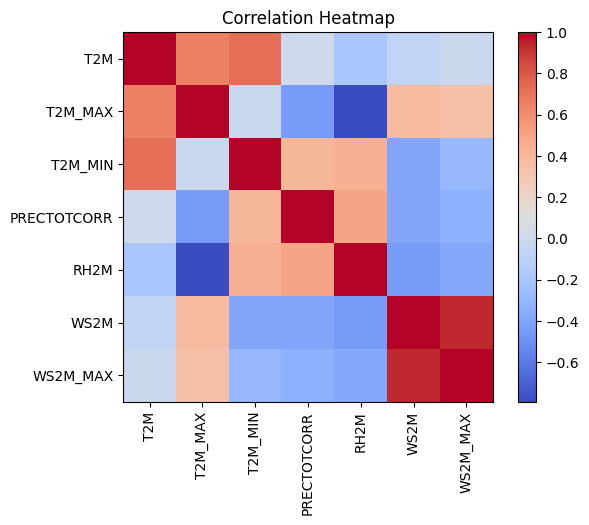

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The correlation analysis shows relationships between climate variables:

- Temperature variables (T2M, T2M_MAX, T2M_MIN) are strongly correlated with each other.
- Rainfall shows weak correlation with temperature, indicating independent seasonal behavior.
- Humidity shows moderate relationship with temperature.

These relationships help understand climate interactions in Ethiopia.

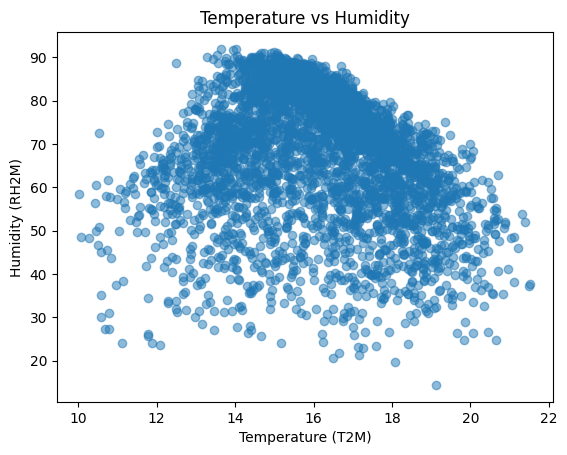

In [30]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

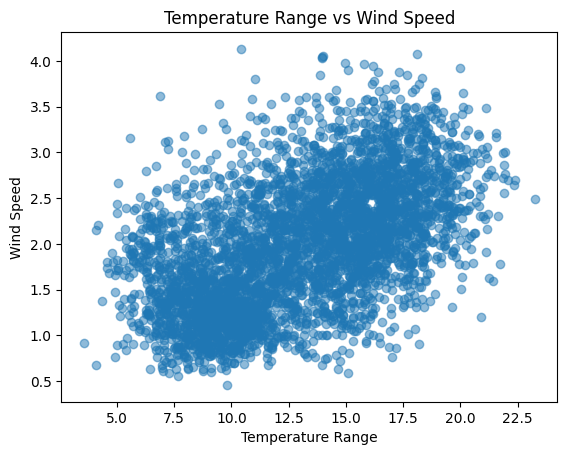

In [31]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()

In [ ]:
## Relationship Analysis (Scatter Plots)

The scatter plots show relationships between climate variables:

- Temperature and humidity show a weak to moderate relationship.
- Temperature range and wind speed show scattered patterns with no strong linear relationship.

This suggests that Ethiopian climate variables interact in complex, non-linear ways.

In [32]:
df.to_csv("../data/ethiopia_clean.csv", index=False)